In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Read the data 
2. EDA
3. Data preparation
4. X & Y
5. train test split
6. Scaling
7. Model training 
8. Model Evaluation

In [2]:
#read the data
df = pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

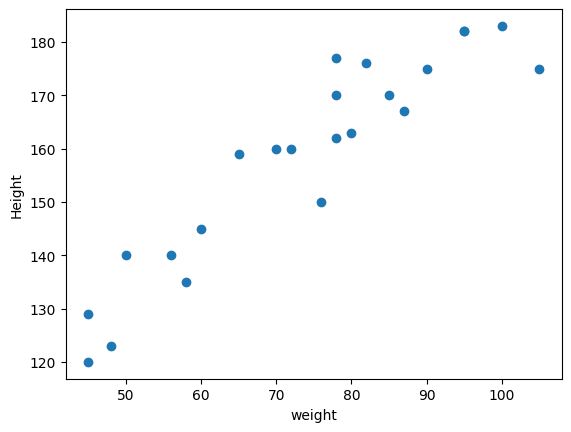

In [4]:
plt.scatter(df.Weight,df.Height)
plt.xlabel('weight')
plt.ylabel('Height')

In [5]:
#problem statement >> I want to predict height based on weight

In [6]:
#divide the data as x and y
x = df[['Weight']]
y = df['Height']

In [7]:
x

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [8]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [9]:
#Train-Test Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=1)

In [10]:
x_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [11]:
x_test

,Weight
20,45
17,65
3,60
13,100
19,87
16,50


In [12]:
y_train

10    176
4     160
2     123
18    150
6     163
7     175
1     135
14    170
0     120
15    177
22    160
21    140
9     170
8     182
12    175
11    182
5     162
Name: Height, dtype: int64

In [13]:
y_test

20    129
17    159
3     145
13    183
19    167
16    140
Name: Height, dtype: int64

In [14]:
#scaling(optional) >> standardization>> fit_transform on train data and transform on test data
#if you fit on test data, (that is wrong) you are doing data Leakage, avoid it
#most of the ml model standardscaler is used as it deals with normal distribution

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

In [17]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [18]:
#scaling should be done after train test split
#target variable should not be scaled 
#avoid scaling categorical features
x_train = scaler.fit_transform(x_train) #for train data use fit_transform
x_test = scaler.transform(x_test)

In [19]:
x_train

array([[ 0.37554243],
       [-0.36825034],
       [-1.73187043],
       [ 0.00364604],
       [ 0.25157697],
       [ 0.87140428],
       [-1.11204312],
       [ 0.56149062],
       [-1.91781863],
       [ 0.12761151],
       [-0.24428488],
       [-1.23600858],
       [ 0.12761151],
       [ 1.18131794],
       [ 1.80114525],
       [ 1.18131794],
       [ 0.12761151]])

In [20]:
x_test

array([[-1.91781863],
       [-0.678164  ],
       [-0.98807766],
       [ 1.49123159],
       [ 0.68545609],
       [-1.60790497]])

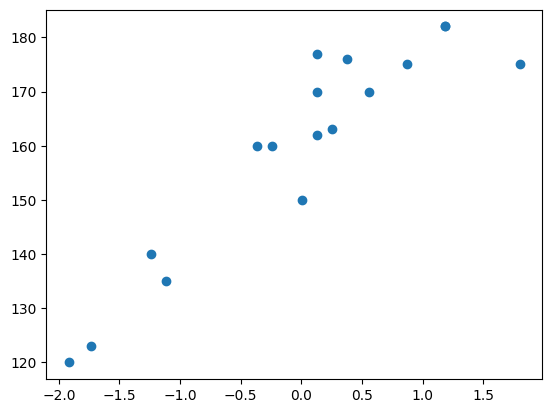

In [21]:
#scaling is optional >> why because it doesn't affect distribution of the data
plt.scatter(x_train,y_train)

In [22]:
#model training
from sklearn.linear_model import LinearRegression

#linear regression parameters
#fit_intercept>> The best fit line will have intercept, by default it is true
#copy_x >> copy the original x_train and build the model, it will not modify the original data
#n_jobs >> -1 means using all the processors
#positive >> When set to true, forces the coefficient to be positive 

#fit>> train the model
#predict>> test the model

#after building the model, you have attributes of the mode; 
#coef_
#intercept

In [23]:
regressor = LinearRegression()

In [24]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
regressor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
regressor.coef_

array([17.7307072])

In [27]:
regressor.intercept_

np.float64(160.0)

In [28]:
print("The slop or coeeficient of model is ",regressor.coef_)
print("The slop or coeeficient of model is ",regressor.intercept_)

The slop or coeeficient of model is  [17.7307072]
The slop or coeeficient of model is  160.0


In [29]:
#prediction on train data 
#interpretation of coef >> one unit increase in weight, on an average the height increase by 17.73 units

#predicted height(y) on x_train = 160 + 17.73 * (x_train)
#predicted height(y) on x_test = 160 + 17.73 * (x_test)


In [30]:
#pred on train data

regressor.predict(x_train)

array([166.65863288, 153.47066096, 129.29271243, 160.06464692,
       164.46063756, 175.45061417, 140.28268904, 169.95562586,
       125.99571945, 162.26264224, 155.66865628, 138.08469371,
       162.26264224, 180.94560247, 191.93557907, 180.94560247,
       162.26264224])

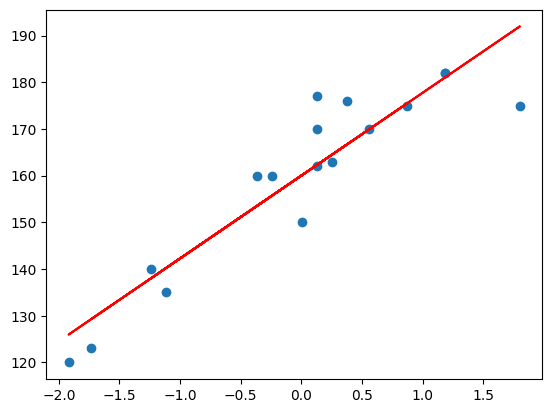

In [31]:
plt.scatter(x_train,y_train)
plt.plot(x_train, regressor.predict(x_train), 'r')

In [32]:
y_pred_test = regressor.predict(x_test)

In [33]:
y_pred_test

array([125.99571945, 147.97567266, 142.48068436, 186.44059077,
       172.15362118, 131.49070775])

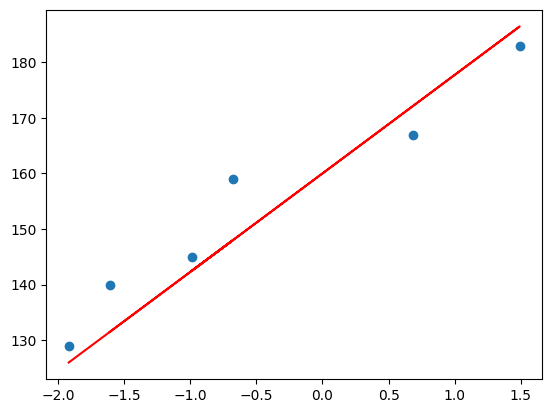

In [34]:
plt.scatter(x_test,y_test)
plt.plot(x_test, regressor.predict(x_test), 'r')

In [35]:
#performance metrix

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [37]:
mean_absolute_error(y_test,y_pred_test)

5.608571289304838

In [38]:
mean_squared_error(y_test, y_pred_test)

41.285662830455514

In [39]:
rsq = r2_score(y_test,y_pred_test) #rsquare = 1-SSR/SST

In [40]:
rsq

0.8721036174256606

In [41]:
#adjusted r Square
#Adjusted R2 = [1-(1-rsquare)*n-1/(n-k-1)] n = number of observation and k = number of predictor variable

In [42]:
x_test.shape

(6, 1)

In [54]:
1-(1-rsq)*(len(y_test)-1)/(len(y_test)-x_test.shape[1] - 1)
#adjusted rsq is always lesser than rsq

0.8401295217820757

In [44]:
#assumption 
#x-y should have linear relation
#observation should have no relation
#error should have constant variation 
#error should have normally distributed
#features among themself should be least related

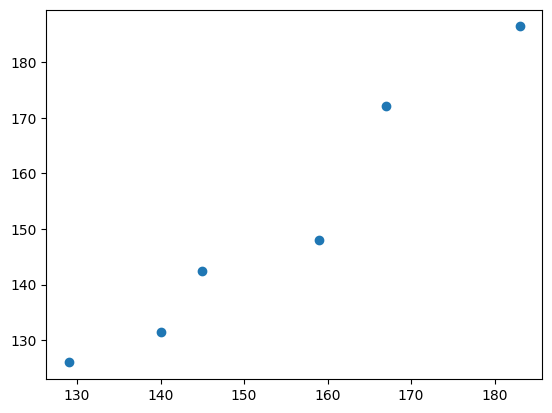

In [45]:
plt.scatter(y_test,y_pred_test)
#to check if y_test and it's predtion align

In [46]:
error = y_test-y_pred_test

In [47]:
error

20     3.004281
17    11.024327
3      2.519316
13    -3.440591
19    -5.153621
16     8.509292
Name: Height, dtype: float64

In [48]:
import seaborn as sns


C:\Users\sagar\AppData\Local\Temp\ipykernel_21416\3836581089.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error)  #approx. normal distribution


<Axes: xlabel='Height', ylabel='Density'>

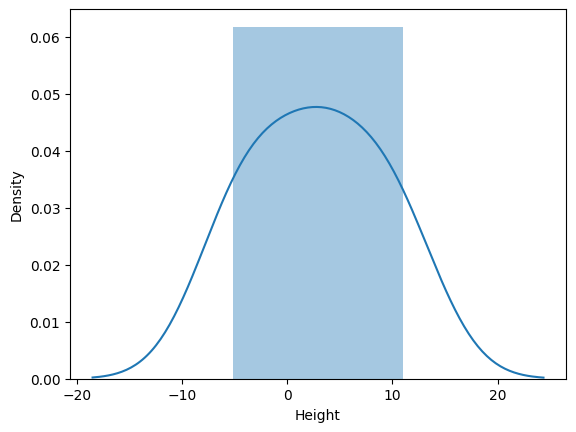

In [49]:
sns.distplot(error)  #approx. normal distribution

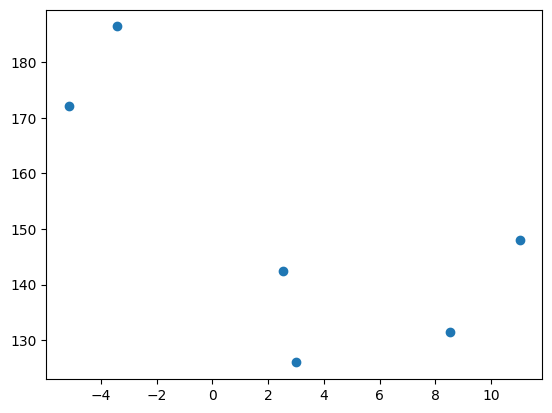

In [50]:
#to check constant variation
plt.scatter(error,y_pred_test)